<a href="https://colab.research.google.com/github/ZiQing-ui/Project/blob/main/Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Neccessary import

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
df = pd.read_csv('/content/FAOSTAT_data_v2.csv')
display(df.head())

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (FBS),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,FBS,Food Balances (2010-),458,Malaysia,5511,Production,S2511,Wheat and products,2010,2010,1000 t,25,I,Value imputed by a receiving agency,NaN
1,FBS,Food Balances (2010-),458,Malaysia,5611,Import quantity,S2511,Wheat and products,2010,2010,1000 t,2078,I,Value imputed by a receiving agency,NaN
2,FBS,Food Balances (2010-),458,Malaysia,5072,Stock Variation,S2511,Wheat and products,2010,2010,1000 t,46,I,Value imputed by a receiving agency,NaN
3,FBS,Food Balances (2010-),458,Malaysia,5911,Export quantity,S2511,Wheat and products,2010,2010,1000 t,501,I,Value imputed by a receiving agency,NaN
4,FBS,Food Balances (2010-),458,Malaysia,5301,Domestic supply quantity,S2511,Wheat and products,2010,2010,1000 t,1557,I,Value imputed by a receiving agency,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8852 entries, 0 to 8851
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       8852 non-null   object 
 1   Domain            8852 non-null   object 
 2   Area Code (M49)   8852 non-null   int64  
 3   Area              8852 non-null   object 
 4   Element Code      8852 non-null   int64  
 5   Element           8852 non-null   object 
 6   Item Code (FBS)   8852 non-null   object 
 7   Item              8852 non-null   object 
 8   Year Code         8852 non-null   int64  
 9   Year              8852 non-null   int64  
 10  Unit              8852 non-null   object 
 11  Value             8852 non-null   int64  
 12  Flag              8852 non-null   object 
 13  Flag Description  8852 non-null   object 
 14  Note              0 non-null      float64
dtypes: float64(1), int64(5), object(9)
memory usage: 1.0+ MB


In [ ]:
df.isna().sum()

,0
Domain Code,0
Domain,0
Area Code (M49),0
Area,0
Element Code,0
Element,0
Item Code (FBS),0
Item,0
Year Code,0
Year,0


In [ ]:
df_clean = df.pivot_table(
    index=['Year', 'Item',],
    columns='Element',
    values='Value',
    aggfunc='sum'
).reset_index()

print("Processed Table:")
display(df_clean.head())

Processed Table:


Element,Year,Item,Domestic supply quantity,Export quantity,Feed,Import quantity,Losses,Other uses (non-food),Processing,Production,Residuals,Seed,Stock Variation
0,2010,"Alcohol, Non-Food",16.0,1.0,NaN,10.0,NaN,16.0,NaN,8.0,0.0,NaN,0.0
1,2010,Apples and products,96.0,47.0,NaN,126.0,NaN,NaN,0.0,NaN,0.0,NaN,-17.0
2,2010,"Aquatic Animals, Others",3.0,4.0,NaN,2.0,NaN,0.0,NaN,5.0,NaN,NaN,0.0
3,2010,Aquatic Plants,208.0,1.0,NaN,2.0,NaN,208.0,NaN,208.0,NaN,NaN,NaN
4,2010,Bananas,313.0,21.0,NaN,2.0,58.0,NaN,NaN,333.0,0.0,NaN,NaN


In [ ]:
output_path = r"malaysia_faostat_FBS_2010_2023.csv"
df_clean.to_csv(output_path, index=False)
print(f"Processed data exported to {output_path}")
print(f"There are {len(df_clean['Item'].unique())} items.")

Processed data exported to malaysia_faostat_FBS_2010_2023.csv
There are 95 items.


In [ ]:
df = pd.read_csv('/content/malaysia_faostat_FBS_2010_2023.csv')

print("Selected Table:")
display(df.head())

Selected Table:


,Year,Item,Domestic supply quantity,Export quantity,Feed,Import quantity,Losses,Other uses (non-food),Processing,Production,Residuals,Seed,Stock Variation
0,2010,"Alcohol, Non-Food",16.0,1.0,NaN,10.0,NaN,16.0,NaN,8.0,0.0,NaN,0.0
1,2010,Apples and products,96.0,47.0,NaN,126.0,NaN,NaN,0.0,NaN,0.0,NaN,-17.0
2,2010,"Aquatic Animals, Others",3.0,4.0,NaN,2.0,NaN,0.0,NaN,5.0,NaN,NaN,0.0
3,2010,Aquatic Plants,208.0,1.0,NaN,2.0,NaN,208.0,NaN,208.0,NaN,NaN,NaN
4,2010,Bananas,313.0,21.0,NaN,2.0,58.0,NaN,NaN,333.0,0.0,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      1330 non-null   int64  
 1   Item                      1330 non-null   object 
 2   Domestic supply quantity  1330 non-null   float64
 3   Export quantity           1305 non-null   float64
 4   Feed                      380 non-null    float64
 5   Import quantity           1325 non-null   float64
 6   Losses                    479 non-null    float64
 7   Other uses (non-food)     382 non-null    float64
 8   Processing                350 non-null    float64
 9   Production                889 non-null    float64
 10  Residuals                 1176 non-null   float64
 11  Seed                      105 non-null    float64
 12  Stock Variation           1131 non-null   float64
dtypes: float64(11), int64(1), object(1)
memory usage: 135.2+ KB


In [ ]:
print(df.isna().sum())

Year                           0
Item                           0
Domestic supply quantity       0
Export quantity               25
Feed                         950
Import quantity                5
Losses                       851
Other uses (non-food)        948
Processing                   980
Production                   441
Residuals                    154
Seed                        1225
Stock Variation              199
dtype: int64


In [ ]:
zero_percentage = (df == 0).sum() / len(df) * 100
print("Percentage of zero values for each column:")
display(zero_percentage.to_frame(name='Zero Percentage').style.format("{:.2f}"))

Percentage of zero values for each column:


,Zero Percentage
Year,0.00
Item,0.00
Domestic supply quantity,6.24
Export quantity,20.68
Feed,9.25
Import quantity,6.47
Losses,8.35
Other uses (non-food),11.35
Processing,4.74
Production,7.29


In [ ]:
df = df.fillna(0)
print(df.isna().sum())

Year                        0
Item                        0
Domestic supply quantity    0
Export quantity             0
Feed                        0
Import quantity             0
Losses                      0
Other uses (non-food)       0
Processing                  0
Production                  0
Residuals                   0
Seed                        0
Stock Variation             0
dtype: int64


In [ ]:
# Rename Column

rename_map = {
    'Domestic supply quantity': 'Domestic_Supply',
    'Export quantity': 'Export',
    'Import quantity': 'Import',
    'Stock Variation': 'Stock_Variation',
    'Production': 'Production',
    'Processing': 'Processing',
    'Losses': 'Losses'
}
df = df.rename(columns=rename_map)
print("Processed Table:")
rows, columns = df.shape

print(f"Total Rows: {rows}")
print(f"Total Columns: {columns}")
display(df.head())

Processed Table:
Total Rows: 1330
Total Columns: 13


,Year,Item,Domestic_Supply,Export,Feed,Import,Losses,Other uses (non-food),Processing,Production,Residuals,Seed,Stock_Variation
0,2010,"Alcohol, Non-Food",16.0,1.0,0.0,10.0,0.0,16.0,0.0,8.0,0.0,0.0,0.0
1,2010,Apples and products,96.0,47.0,0.0,126.0,0.0,0.0,0.0,0.0,0.0,0.0,-17.0
2,2010,"Aquatic Animals, Others",3.0,4.0,0.0,2.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0
3,2010,Aquatic Plants,208.0,1.0,0.0,2.0,0.0,208.0,0.0,208.0,0.0,0.0,0.0
4,2010,Bananas,313.0,21.0,0.0,2.0,58.0,0.0,0.0,333.0,0.0,0.0,0.0


In [ ]:
total_items = sorted(df["Item"].unique())
print("=== FBS Items (Total:", len(total_items), ") ===")
for item in total_items:
    print(item)

=== FBS Items (Total: 95 ) ===
Alcohol, Non-Food
Apples and products
Aquatic Animals, Others
Aquatic Plants
Bananas
Barley and products
Beans
Beer
Beverages, Alcoholic
Beverages, Fermented
Bovine Meat
Butter, Ghee
Cassava and products
Cephalopods
Cereals, other
Citrus, Other
Cloves
Cocoa Beans and products
Coconut Oil
Coconuts - Incl Copra
Coffee and products
Cottonseed
Cottonseed Oil
Cream
Crustaceans
Dates
Demersal Fish
Eggs
Fats, Animals, Raw
Fish, Body Oil
Fish, Liver Oil
Freshwater Fish
Fruits, other
Grapefruit and products
Grapes and products (excl wine)
Groundnut Oil
Groundnuts
Honey
Infant food
Lemons, Limes and products
Maize Germ Oil
Maize and products
Marine Fish, Other
Meat, Other
Milk - Excluding Butter
Millet and products
Miscellaneous
Molluscs, Other
Mutton & Goat Meat
Nuts and products
Oats
Offals, Edible
Oilcrops Oil, Other
Oilcrops, Other
Olive Oil
Olives (including preserved)
Onions
Oranges, Mandarines
Palm Oil
Palm kernels
Palmkernel Oil
Peas
Pelagic Fish
Pepper
Pig

In [ ]:
total_items_df = pd.DataFrame(total_items, columns=['Item'])
total_items_df.to_csv('/content/item_list.csv', index=False)
print("total_items_df exported to /content/item_list.csv")

total_items_df exported to /content/item_list.csv


In [ ]:
# Check for items that do not have the full year range (2010-2023)

year_range_check = df.groupby('Item')['Year'].agg(['min', 'max'])

items_outside_range = year_range_check[
    (year_range_check['min'] != 2010) | (year_range_check['max'] != 2023)
]

if items_outside_range.empty:
    print("All unique items have data spanning the entire year range from 2010 to 2023.")
else:
    print("The following items do not have data spanning the entire year range from 2010 to 2023:")
    display(items_outside_range)

All unique items have data spanning the entire year range from 2010 to 2023.


/tmp/ipython-input-2836409866.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


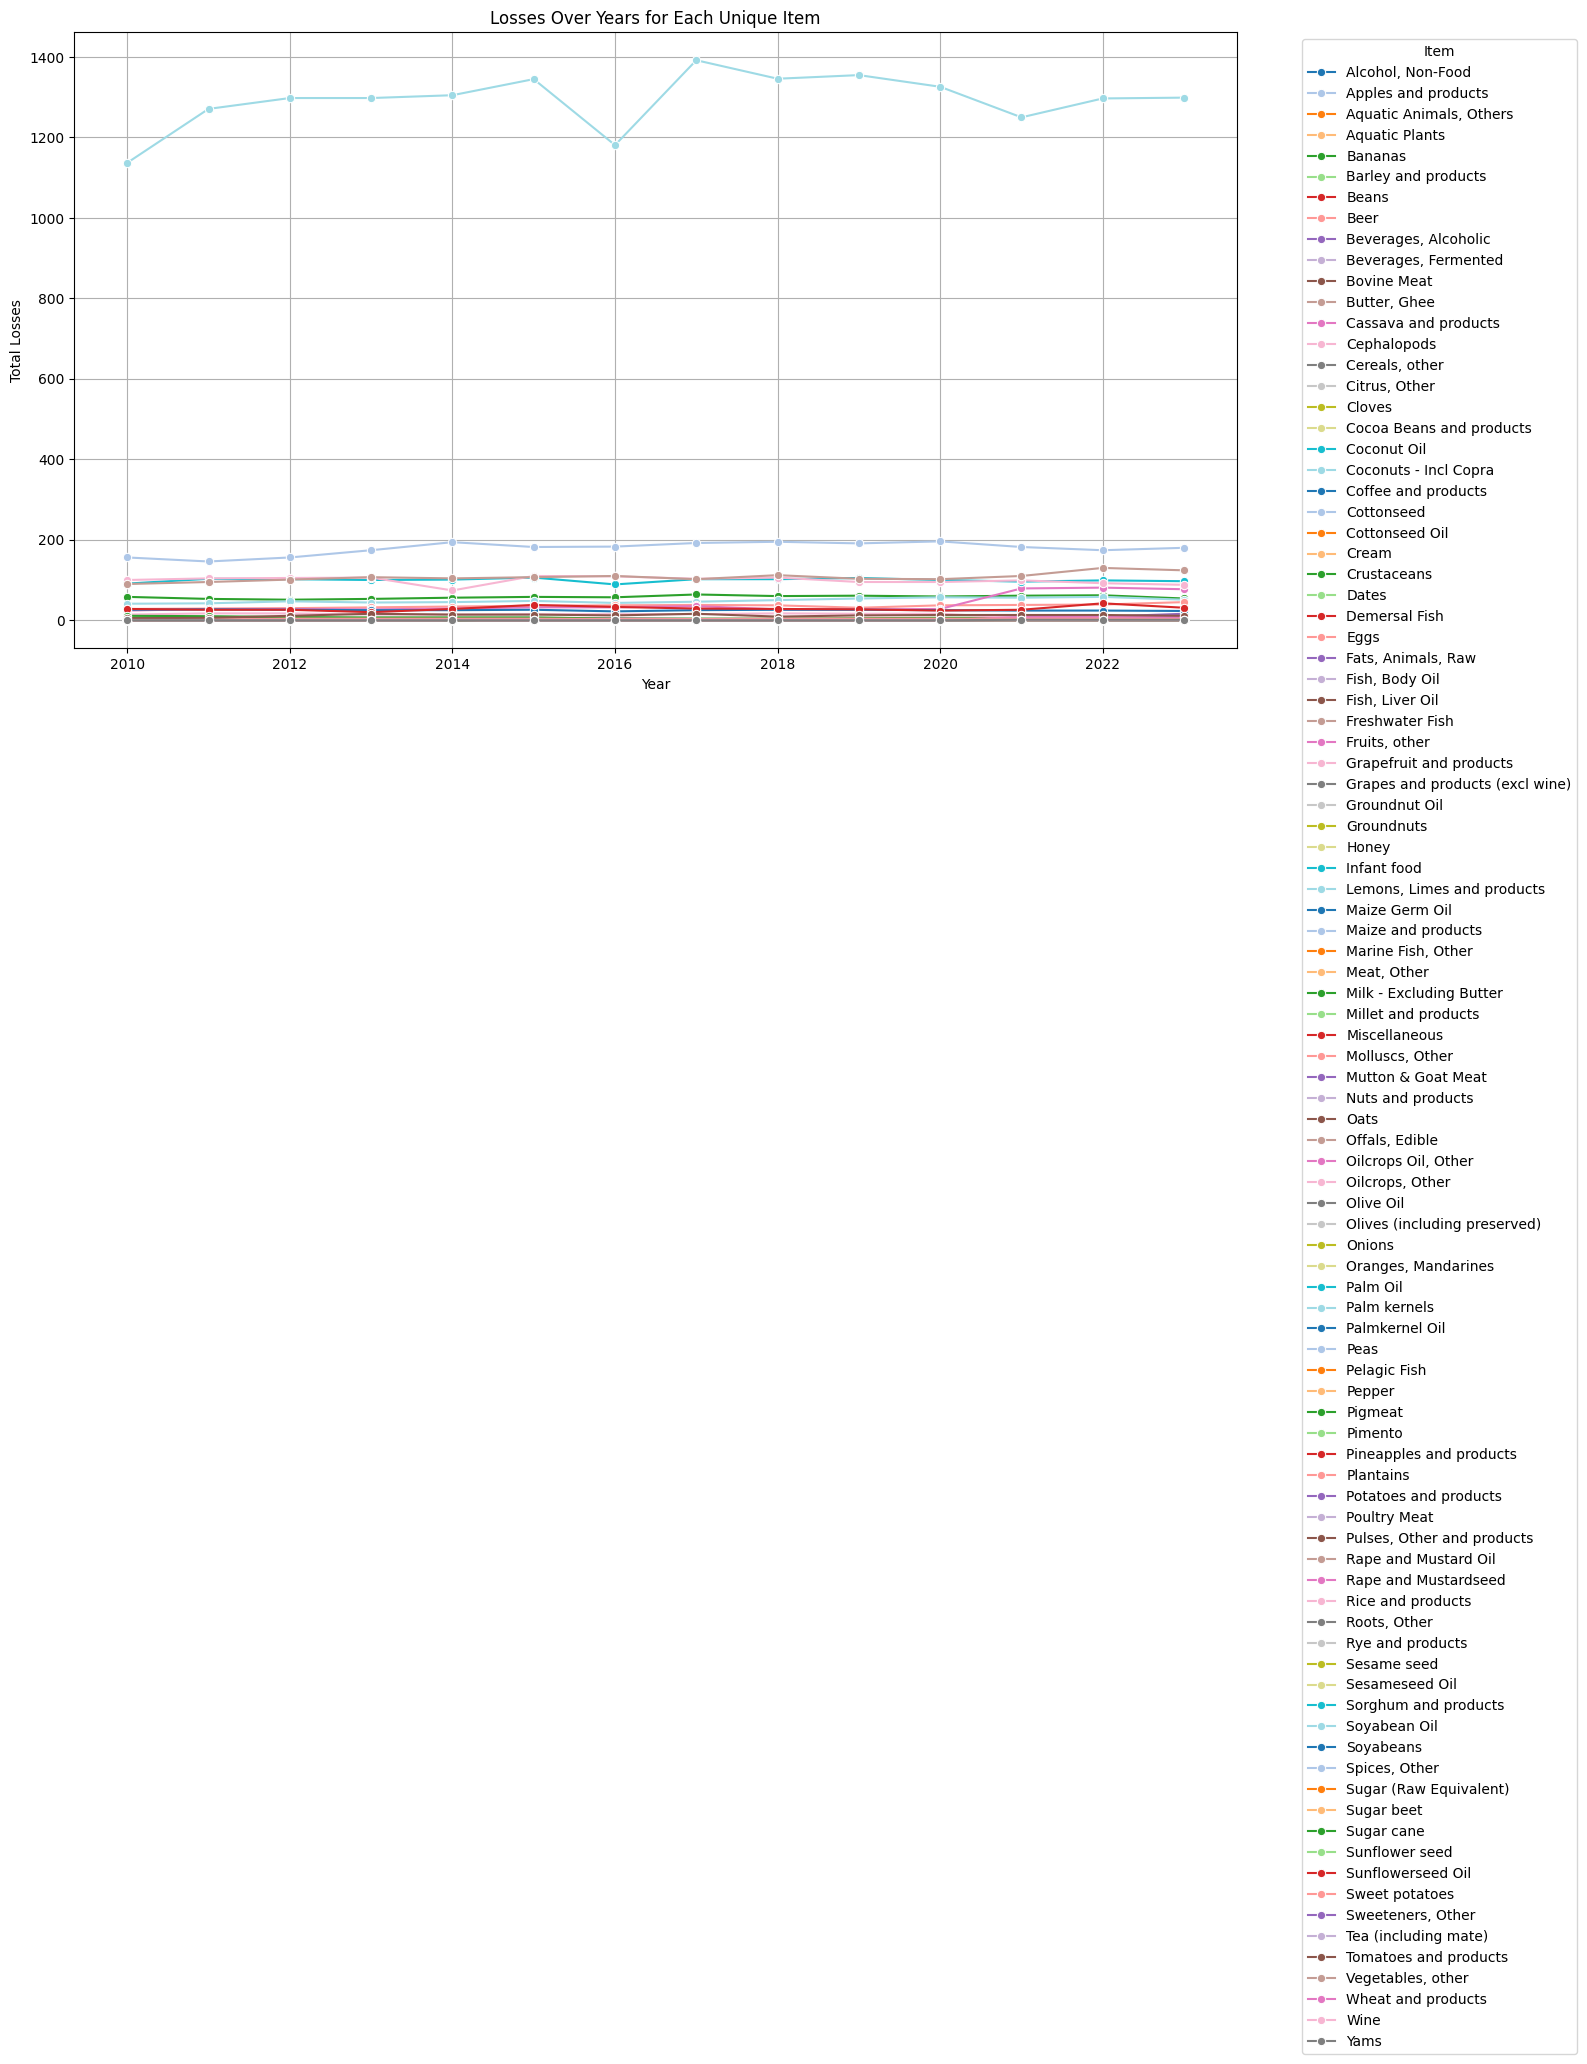

In [ ]:
# Group by Item and Year and sum the 'Losses'
losses_by_item_year = df.groupby(['Item', 'Year'])['Losses'].sum().reset_index()

# Plotting
plt.figure(figsize=(15, 8))
sns.lineplot(data=losses_by_item_year, x='Year', y='Losses', hue='Item', marker='o', palette='tab20')

plt.title('Losses Over Years for Each Unique Item')
plt.xlabel('Year')
plt.ylabel('Total Losses')
plt.legend(title='Item', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
total_losses_per_item = losses_by_item_year.groupby('Item')['Losses'].sum().reset_index(name='Losses')
print("Total losses per item:")
display(total_losses_per_item)

Total losses per item:


,Item,Losses
0,"Alcohol, Non-Food",0.0
1,Apples and products,0.0
2,"Aquatic Animals, Others",0.0
3,Aquatic Plants,0.0
4,Bananas,807.0
...,...,...
90,Tomatoes and products,165.0
91,"Vegetables, other",1497.0
92,Wheat and products,0.0
93,Wine,0.0


In [ ]:
items_with_zero_losses = total_losses_per_item[total_losses_per_item['Losses'] == 0]
print("Items with consistently zero losses across all years:")
display(items_with_zero_losses)

Items with consistently zero losses across all years:


,Item,Losses
0,"Alcohol, Non-Food",0.0
1,Apples and products,0.0
2,"Aquatic Animals, Others",0.0
3,Aquatic Plants,0.0
5,Barley and products,0.0
...,...,...
85,Sunflower seed,0.0
86,Sunflowerseed Oil,0.0
88,"Sweeteners, Other",0.0
92,Wheat and products,0.0


In [ ]:
num_zero_losses_items = len(items_with_zero_losses)
print(f"There are {num_zero_losses_items} items with consistently zero losses.")

There are 64 items with consistently zero losses.


In [ ]:
# Removing items that are zero losses throughout year 2010 to 2023

items_to_remove = items_with_zero_losses['Item'].tolist()
df_filtered = df[~df['Item'].isin(items_to_remove)]

print(f"Original df had {len(df['Item'].unique())} unique items.")
print(f"After removing items with zero losses, df_filtered has {len(df_filtered['Item'].unique())} unique items.")
display(df_filtered.head())

Original df had 95 unique items.
After removing items with zero losses, df_filtered has 31 unique items.


,Year,Item,Domestic_Supply,Export,Feed,Import,Losses,Other uses (non-food),Processing,Production,Residuals,Seed,Stock_Variation
4,2010,Bananas,313.0,21.0,0.0,2.0,58.0,0.0,0.0,333.0,0.0,0.0,0.0
12,2010,Cassava and products,3518.0,3.0,1.0,3484.0,3.0,3474.0,0.0,37.0,0.0,0.0,0.0
15,2010,"Citrus, Other",7.0,0.0,0.0,1.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0
19,2010,Coconuts - Incl Copra,681.0,54.0,6.0,168.0,41.0,55.0,384.0,550.0,0.0,0.0,-16.0
20,2010,Coffee and products,-80.0,193.0,0.0,97.0,1.0,0.0,0.0,16.0,-81.0,0.0,0.0


In [ ]:
filtered_losses_by_item_year = df_filtered.groupby(['Item', 'Year'])['Losses'].sum().reset_index()

print("Filtered losses by item and year:")

display(filtered_losses_by_item_year)

Filtered losses by item and year:


,Item,Year,Losses
0,Bananas,2010,58.0
1,Bananas,2011,53.0
2,Bananas,2012,51.0
3,Bananas,2013,53.0
4,Bananas,2014,56.0
...,...,...,...
429,Yams,2019,0.0
430,Yams,2020,0.0
431,Yams,2021,1.0
432,Yams,2022,1.0


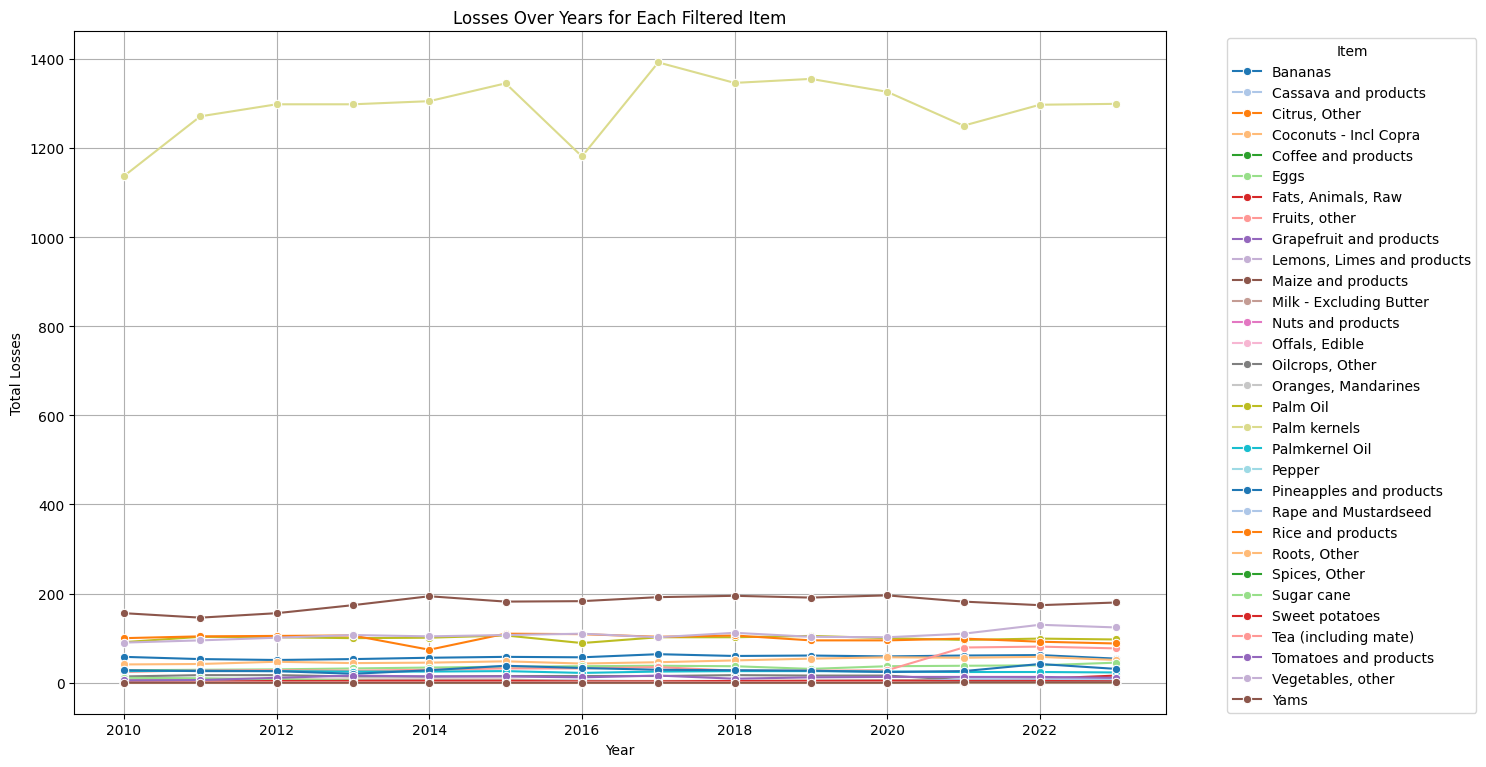

In [ ]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=filtered_losses_by_item_year, x='Year', y='Losses', hue='Item', marker='o', palette='tab20')

plt.title('Losses Over Years for Each Filtered Item')
plt.xlabel('Year')
plt.ylabel('Total Losses')
plt.legend(title='Item', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
top10_highest_losses_items = df.groupby('Item')['Losses'].sum().nlargest(10).reset_index()
top10_highest_losses_items.columns = ['Item', 'Total Losses']
print("Top 10 Items with Highest Total Losses:")
display(top10_highest_losses_items)

Top 10 Items with Highest Total Losses:


,Item,Total Losses
0,Palm kernels,18100.0
1,Maize and products,2501.0
2,"Vegetables, other",1497.0
3,Palm Oil,1393.0
4,Rice and products,1386.0
5,Bananas,807.0
6,Coconuts - Incl Copra,682.0
7,"Fruits, other",554.0
8,Eggs,491.0
9,Pineapples and products,406.0


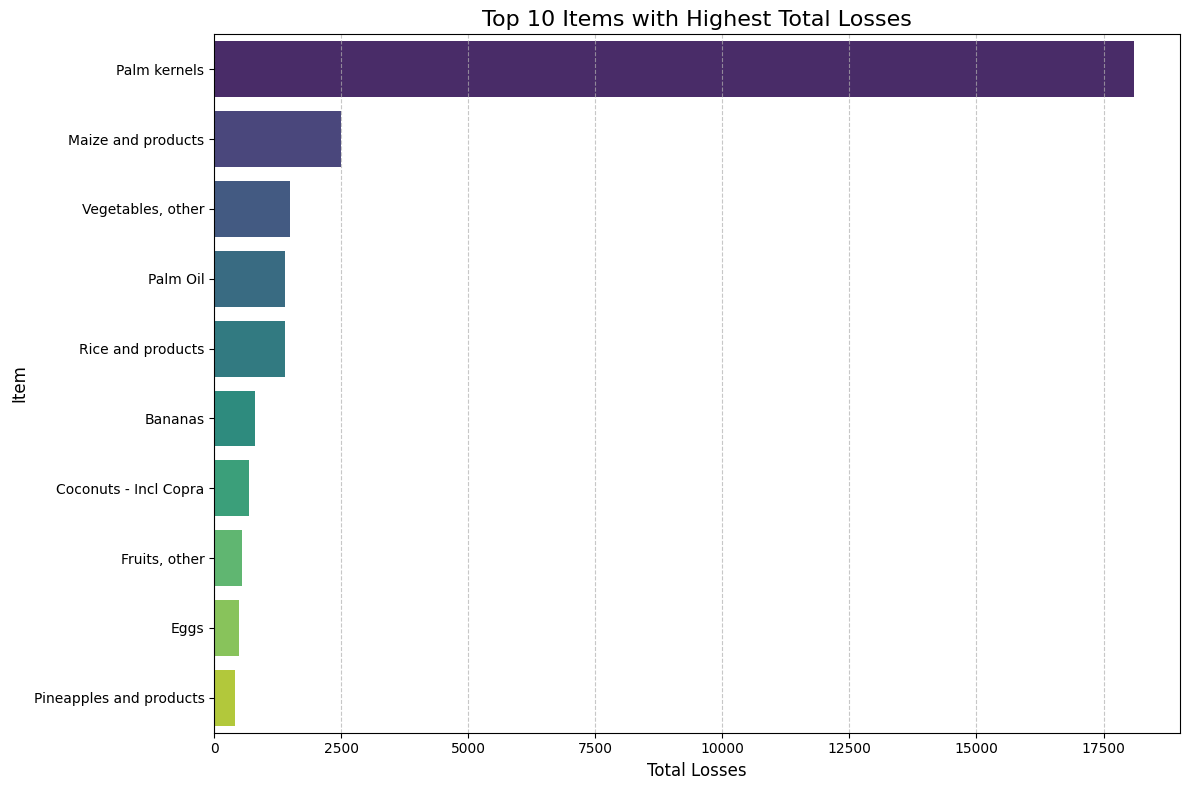

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Total Losses', y='Item', data=top10_highest_losses_items, hue='Item', palette='viridis', legend=False)
plt.title('Top 10 Items with Highest Total Losses', fontsize=16)
plt.xlabel('Total Losses', fontsize=12)
plt.ylabel('Item', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
output_path = '/content/malaysia_faostat_FBS_2010_2023_selected_items.csv'
df_filtered.to_csv(output_path, index=False)
print(f"DataFrame saved to {output_path}")

DataFrame saved to /content/malaysia_faostat_FBS_2010_2023_selected_items.csv


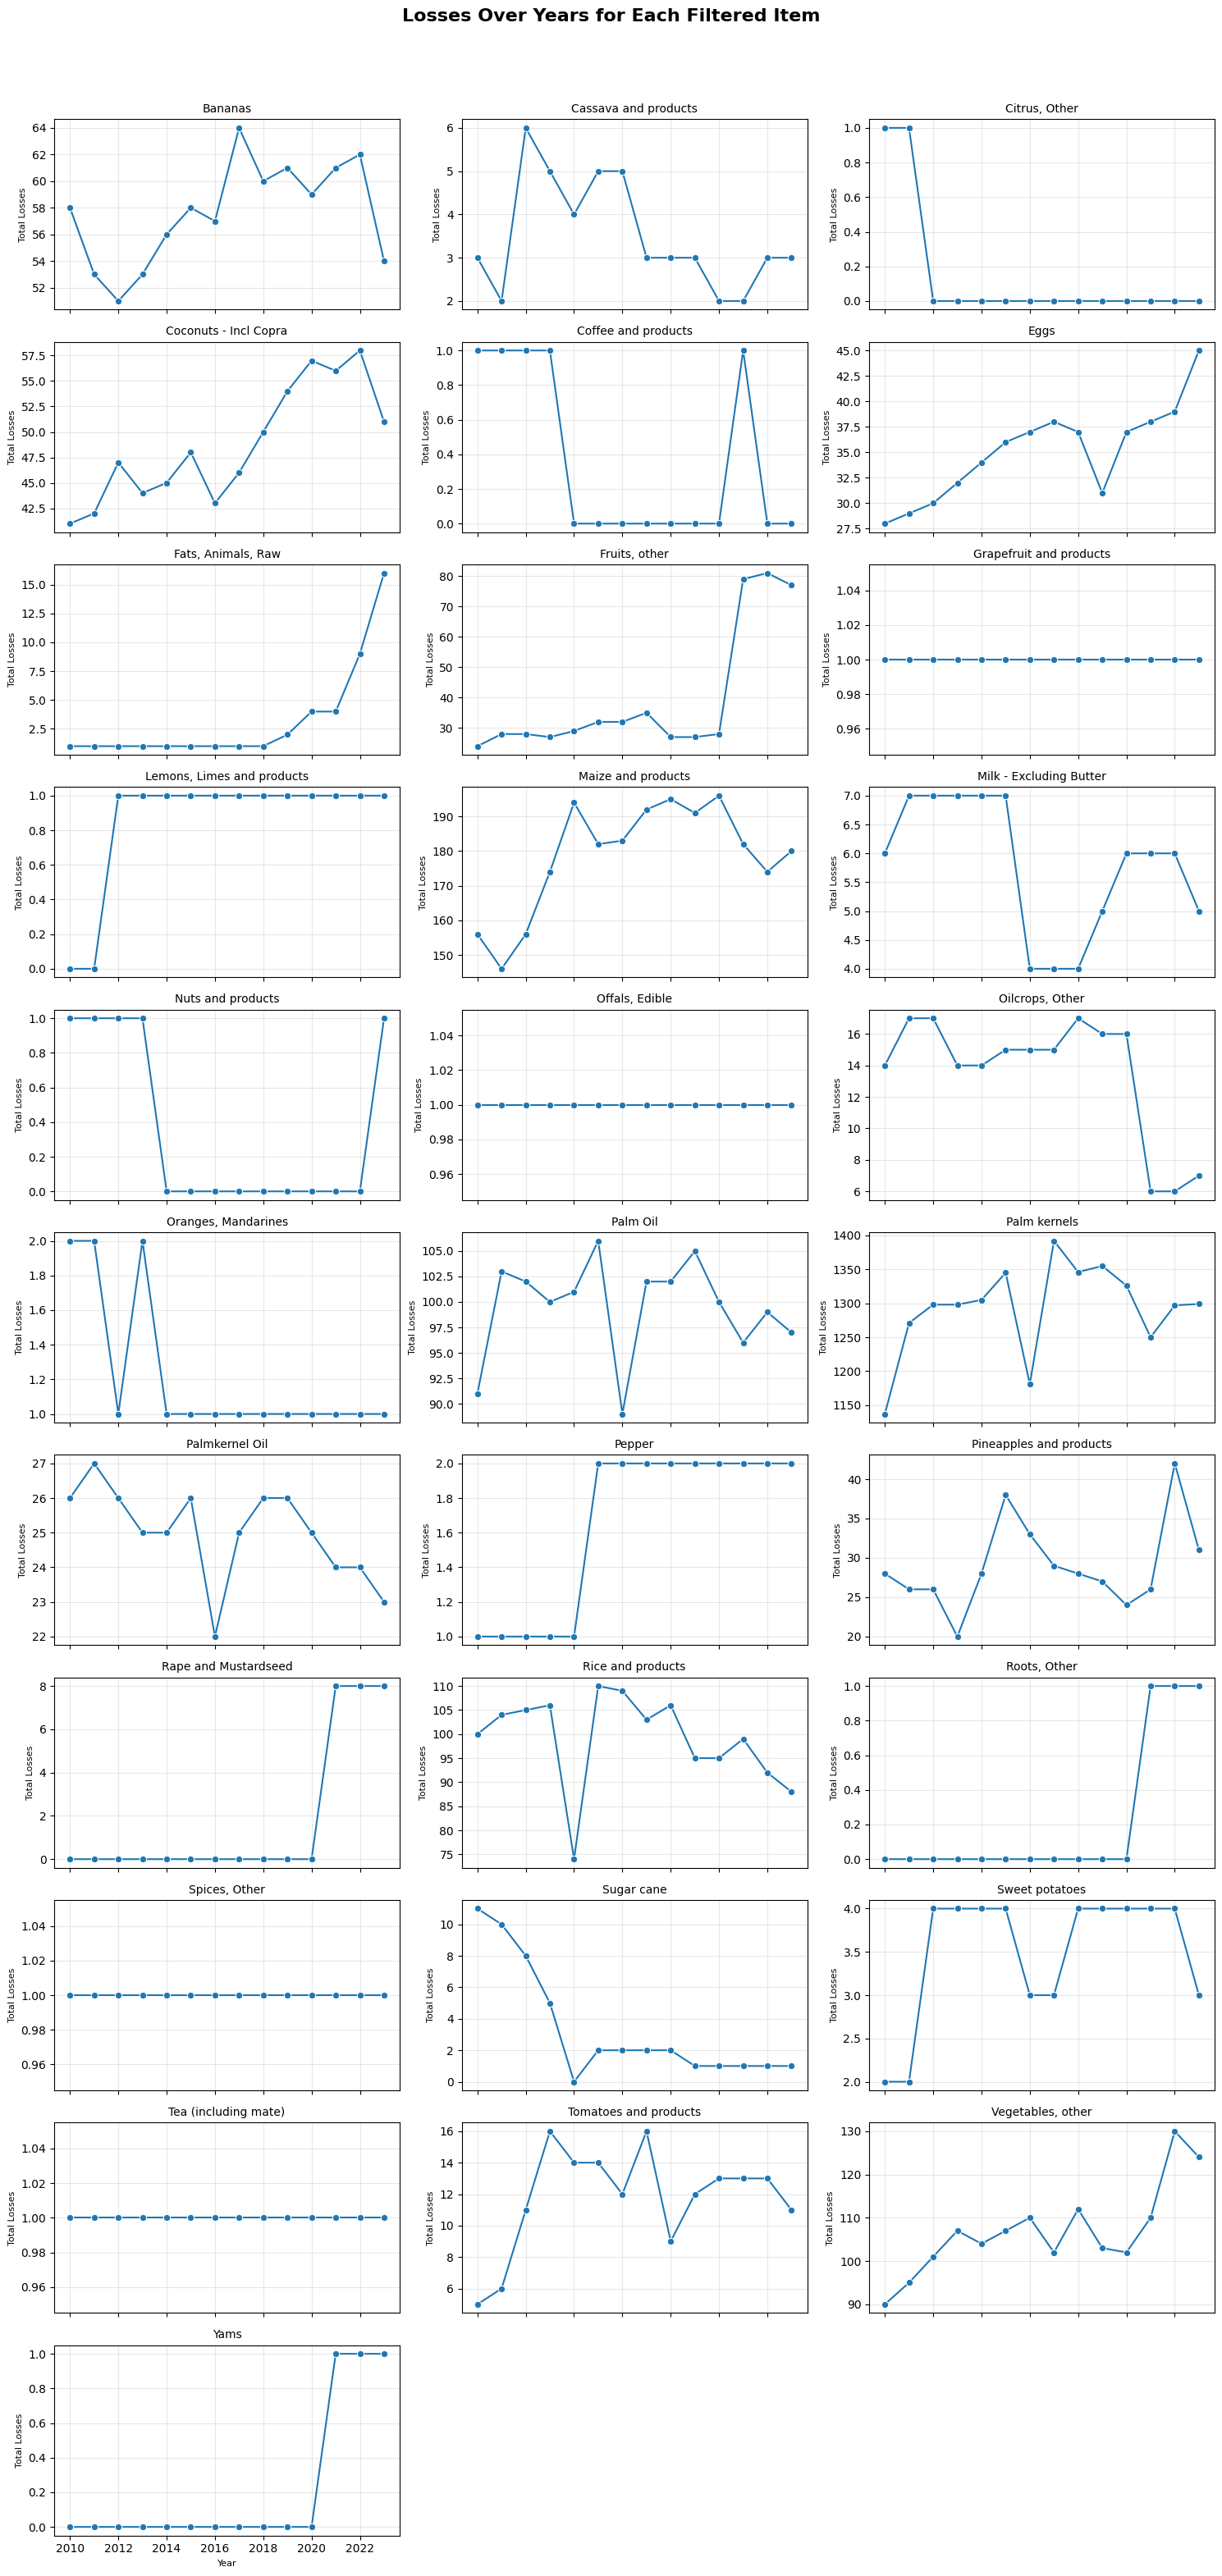

In [ ]:
# Get a list of all unique items
unique_items = filtered_losses_by_item_year['Item'].unique()
num_items = len(unique_items)

# Determine the grid size for subplots
num_cols = 3  # You can adjust this number
num_rows = math.ceil(num_items / num_cols)

# Create a single figure with a grid of subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, num_rows * 3), sharex=True)
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

fig.suptitle('Losses Over Years for Each Filtered Item', fontsize=16, fontweight='bold')

# Iterate through each unique item and plot on a subplot
for i, item in enumerate(unique_items):
    # Filter data for the current item
    item_data = filtered_losses_by_item_year[filtered_losses_by_item_year['Item'] == item]

    sns.lineplot(data=item_data, x='Year', y='Losses', marker='o', ax=axes[i])
    axes[i].set_title(item, fontsize=10)
    axes[i].set_xlabel('Year', fontsize=8)  # Smaller labels for subplots
    axes[i].set_ylabel('Total Losses', fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Turn off any unused subplots if the number of items is not a perfect multiple of num_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust rect to make space for suptitle
plt.show()

In [ ]:
df = pd.read_csv('/content/malaysia_faostat_FBS_2010_2023_selected_items.csv')

print("Selected Table:")
display(df)

Selected Table:


,Year,Item,Domestic_Supply,Export,Feed,Import,Losses,Other uses (non-food),Processing,Production,Residuals,Seed,Stock_Variation
0,2010,Bananas,313.0,21.0,0.0,2.0,58.0,0.0,0.0,333.0,0.0,0.0,0.0
1,2010,Cassava and products,3518.0,3.0,1.0,3484.0,3.0,3474.0,0.0,37.0,0.0,0.0,0.0
2,2010,"Citrus, Other",7.0,0.0,0.0,1.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0
3,2010,Coconuts - Incl Copra,681.0,54.0,6.0,168.0,41.0,55.0,384.0,550.0,0.0,0.0,-16.0
4,2010,Coffee and products,-80.0,193.0,0.0,97.0,1.0,0.0,0.0,16.0,-81.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
429,2023,Sweet potatoes,45.0,2.0,20.0,22.0,3.0,0.0,0.0,26.0,0.0,2.0,0.0
430,2023,Tea (including mate),39.0,15.0,0.0,39.0,1.0,0.0,0.0,16.0,-6.0,0.0,0.0
431,2023,Tomatoes and products,227.0,77.0,0.0,141.0,11.0,0.0,0.0,164.0,0.0,0.0,0.0
432,2023,"Vegetables, other",1640.0,740.0,0.0,1101.0,124.0,0.0,0.0,1210.0,-8.0,0.0,-69.0


In [ ]:
# =========================
# 1. Self-Sufficiency Ratio (SSR)
# =========================
# Formula: Production / (Production + Imports - Exports ± ΔStocks) * 100
denominator = (
    df["Production"]
    + df["Import"]
    - df["Export"]
    + df["Stock_Variation"]
)

df["SSR (%)"] = (df["Production"] / denominator.replace(0, pd.NA) * 100)

# =========================
# 2. Import Dependency Ratio (IDR)
# =========================
# Formula: Imports / (Production + Imports - Exports ± ΔStocks) * 100
df["IDR (%)"] = (df["Import"] / denominator.replace(0, pd.NA) * 100)

# =========================
# 3. Per-Capita Availability(,000)
# =========================

population_data = {
    2010: 28655.78,
    2011: 29162.04,
    2012: 29662.83,
    2013: 30174.26,
    2014: 30696.14,
    2015: 31232.80,
    2016: 31789.69,
    2017: 32355.64,
    2018: 32910.97,
    2019: 33440.60,
    2020: 33889.56,
    2021: 34282.40,
    2022: 34695.49,
    2023: 35126.30
}
df["Population"] = df["Year"].map(population_data)

# Domestic availability = Production + Imports - Exports + Stock Variation
df["Domestic_Availability"] = (
    df["Production"] + df["Import"] - df["Export"] + df["Stock_Variation"]
)

df["PerCapita_Availability"] = (
    df["Domestic_Availability"] / df["Population"]
).round(6)  # tons/person

df["PerCapita_Availability_kg"] = (df["PerCapita_Availability"] * 1000).round(2)

# =========================
# Save enriched dataset
# =========================
df.to_csv("malaysia_faostat_fbs_features.csv", index=False)

print("✅ Feature engineering (FAO formula) complete.")
print("New file saved: malaysia_faostat_fbs_features.csv")
print("Columns added: ['SSR (%)','IDR (%)','Population','Domestic_Availability','PerCapita_Availability','PerCapita_Availability_kg']")


✅ Feature engineering (FAO formula) complete.
New file saved: malaysia_faostat_fbs_features.csv
Columns added: ['SSR (%)','IDR (%)','Population','Domestic_Availability','PerCapita_Availability','PerCapita_Availability_kg']


In [ ]:
df = pd.read_csv('/content/malaysia_faostat_fbs_features.csv')

print("Selected Table:")
display(df)

Selected Table:


,Year,Item,Domestic_Supply,Export,Feed,Import,Losses,Other uses (non-food),Processing,Production,Residuals,Seed,Stock_Variation,SSR (%),IDR (%),Population,Domestic_Availability,PerCapita_Availability,PerCapita_Availability_kg
0,2010,Bananas,313.0,21.0,0.0,2.0,58.0,0.0,0.0,333.0,0.0,0.0,0.0,106.050955,0.636943,28655.78,314.0,0.010958,10.96
1,2010,Cassava and products,3518.0,3.0,1.0,3484.0,3.0,3474.0,0.0,37.0,0.0,0.0,0.0,1.051734,99.033542,28655.78,3518.0,0.122768,122.77
2,2010,"Citrus, Other",7.0,0.0,0.0,1.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0,85.714286,14.285714,28655.78,7.0,0.000244,0.24
3,2010,Coconuts - Incl Copra,681.0,54.0,6.0,168.0,41.0,55.0,384.0,550.0,0.0,0.0,-16.0,84.876543,25.925926,28655.78,648.0,0.022613,22.61
4,2010,Coffee and products,-80.0,193.0,0.0,97.0,1.0,0.0,0.0,16.0,-81.0,0.0,0.0,-20.000000,-121.250000,28655.78,-80.0,-0.002792,-2.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429,2023,Sweet potatoes,45.0,2.0,20.0,22.0,3.0,0.0,0.0,26.0,0.0,2.0,0.0,56.521739,47.826087,35126.30,46.0,0.001310,1.31
430,2023,Tea (including mate),39.0,15.0,0.0,39.0,1.0,0.0,0.0,16.0,-6.0,0.0,0.0,40.000000,97.500000,35126.30,40.0,0.001139,1.14
431,2023,Tomatoes and products,227.0,77.0,0.0,141.0,11.0,0.0,0.0,164.0,0.0,0.0,0.0,71.929825,61.842105,35126.30,228.0,0.006491,6.49
432,2023,"Vegetables, other",1640.0,740.0,0.0,1101.0,124.0,0.0,0.0,1210.0,-8.0,0.0,-69.0,80.559254,73.302264,35126.30,1502.0,0.042760,42.76


In [ ]:
# Check duplication years
duplicate_years_per_item = df[df.duplicated(subset=['Item', 'Year'], keep=False)]

if not duplicate_years_per_item.empty:
    print("Items with duplicate years found:")
    for item in duplicate_years_per_item['Item'].unique():
        years_with_duplicates = duplicate_years_per_item[duplicate_years_per_item['Item'] == item]['Year'].unique()
        print(f"  - {item}: {sorted(years_with_duplicates.tolist())}")
else:
    print("No duplicate years found for any item.")

No duplicate years found for any item.


In [ ]:
# ==================================
# EDA for target variables : Losses
# ==================================

stats = df['Losses'].describe()
skew = df['Losses'].skew()
kurt = df['Losses'].kurt()
print("--- Descriptive Statistics for Losses ---")
print(stats)
print(f"\nSkewness: {skew:.4f}")
print(f"Kurtosis: {kurt:.4f}")

# Interpretation for Thesis:
# High skewness (>1) suggests the data is heavily right-tailed,
# justifying the use of Min-Max Scaling or Log Transformation.

--- Descriptive Statistics for Losses ---
count     434.000000
mean       66.684332
std       228.323419
min         0.000000
25%         1.000000
50%         4.000000
75%        37.000000
max      1392.000000
Name: Losses, dtype: float64

Skewness: 5.0625
Kurtosis: 24.7032


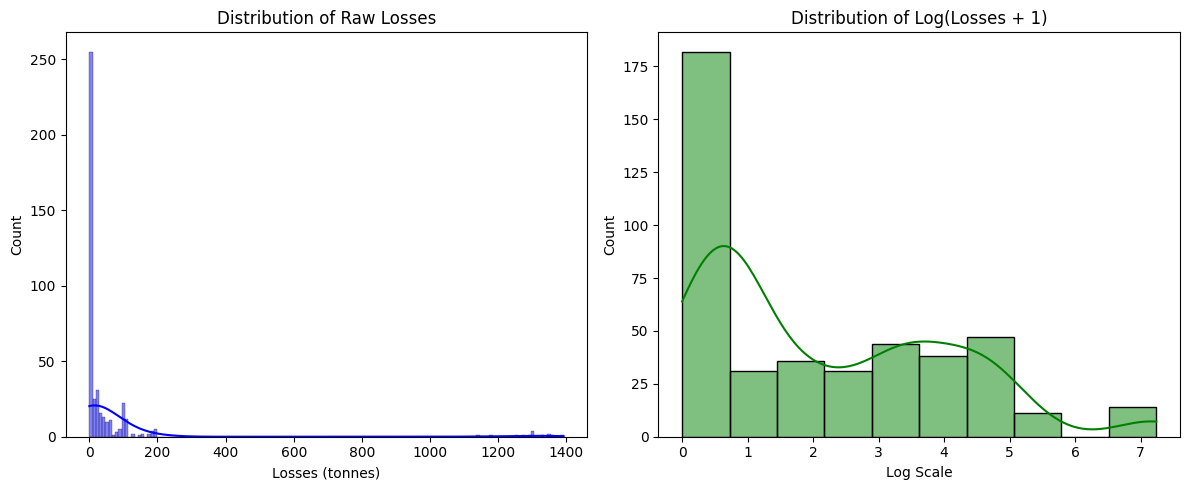

In [ ]:
# Distribution Visualization
plt.figure(figsize=(12, 5))

# Plot 1: Raw Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Losses'], kde=True, color='blue')
plt.title('Distribution of Raw Losses')
plt.xlabel('Losses (tonnes)')

# Plot 2: Log Distribution (to see if normalization is possible)
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['Losses']), kde=True, color='green')
plt.title('Distribution of Log(Losses + 1)')
plt.xlabel('Log Scale')

plt.tight_layout()
plt.show()

/tmp/ipython-input-2456787944.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset_df, x='Item', y='Losses', palette='Set3')


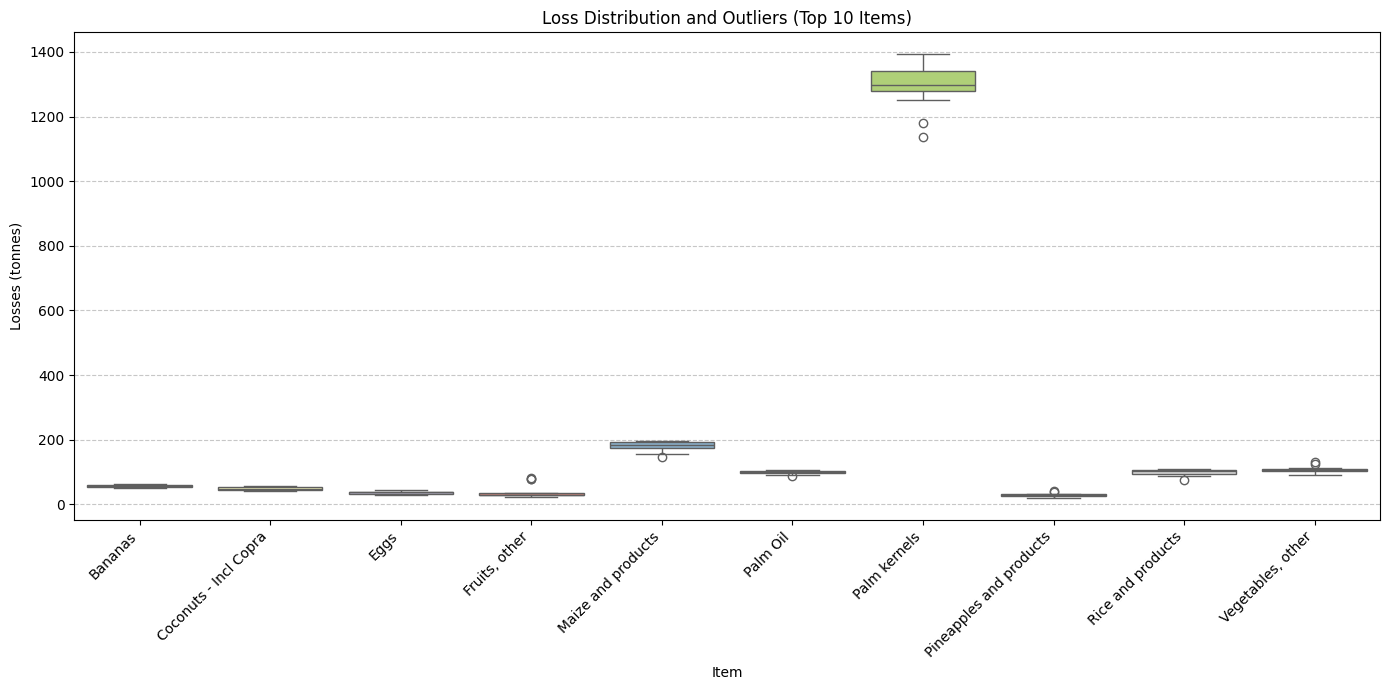

In [ ]:
plt.figure(figsize=(14, 7))

# Identify top 10 items by total loss for a cleaner plot
top_10_items = df.groupby('Item')['Losses'].sum().nlargest(10).index
subset_df = df[df['Item'].isin(top_10_items)]

sns.boxplot(data=subset_df, x='Item', y='Losses', palette='Set3')
plt.xticks(rotation=45, ha='right')
plt.title('Loss Distribution and Outliers (Top 10 Items)')
plt.ylabel('Losses (tonnes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Interpretation for Thesis:
# The "dots" above the boxes are individual years of extreme loss (outliers),
# proving why the IQR Outlier Detection in Step 5 was necessary.

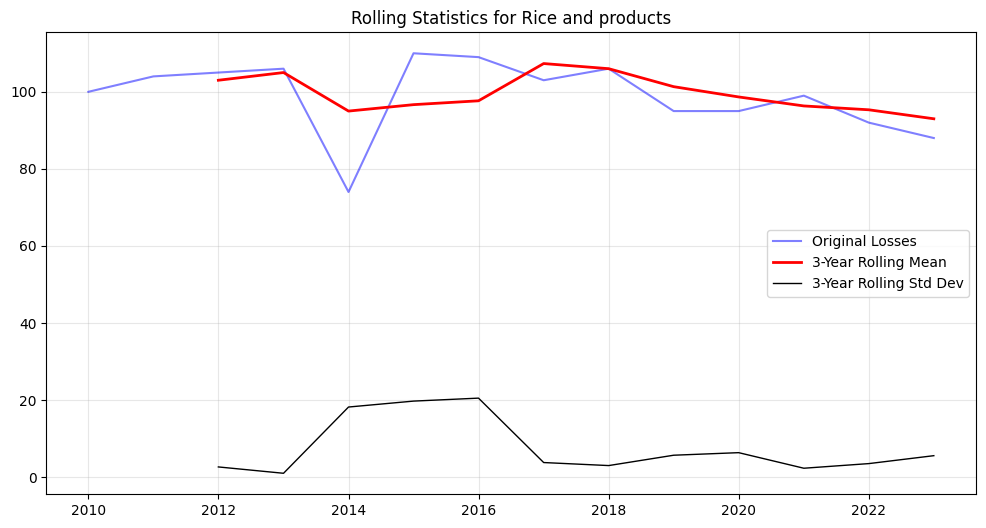

In [ ]:
# Sample: Check stability for 'Rice and products'
item_name = 'Rice and products'
sample_df = df[df['Item'] == item_name].copy()
sample_df['Year'] = pd.to_datetime(sample_df['Year'].astype(str), format='%Y')
sample_df = sample_df.sort_values('Year').set_index('Year')

# Calculate 3-Year Rolling Mean and Std Dev
rolmean = sample_df['Losses'].rolling(window=3).mean()
rolstd = sample_df['Losses'].rolling(window=3).std()

plt.figure(figsize=(12, 6))
plt.plot(sample_df['Losses'], color='blue', label='Original Losses', alpha=0.5)
plt.plot(rolmean, color='red', label='3-Year Rolling Mean', linewidth=2)
plt.plot(rolstd, color='black', label='3-Year Rolling Std Dev', linewidth=1)

plt.title(f'Rolling Statistics for {item_name}')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Interpretation for Thesis:
# If the Red and Black lines are not flat, the series has a trend or
# changing variance, necessitating STL decomposition and ADF testing.

In [ ]:
df_original = pd.read_csv('malaysia_faostat_fbs_features.csv')
results = []

for item in unique_items:
    item_df = df_original[df_original['Item'] == item].copy()
    item_df['Year'] = pd.to_datetime(item_df['Year'].astype(str), format='%Y')
    item_df = item_df.set_index('Year').asfreq('YS')

    if 'Losses' in item_df.columns and len(item_df['Losses'].dropna()) > 10:
        item_df['Losses'] = item_df['Losses'].interpolate(method='linear')

        try:
            # Fit both models
            res3 = STL(item_df['Losses'], period=3, robust=True).fit()
            res4 = STL(item_df['Losses'], period=4, robust=True).fit()

            # Calculate Strength Score (0 to 1)
            def strength(res):
                return max(0, 1 - res.resid.var() / (res.seasonal + res.resid).var())

            s3, s4 = strength(res3), strength(res4)

            # Determine "Winner"
            winner = 4 if s4 > s3 else 3
            margin = abs(s4 - s3)

            results.append({
                'Item': item,
                'Strength_P3': round(s3, 3),
                'Strength_P4': round(s4, 3),
                'Winning_Period': winner,
                'Confidence': "High" if margin > 0.1 else "Low"
            })

        except:
            continue

# Create and display the summary table
summary_df = pd.DataFrame(results)
print(summary_df.sort_values(by='Strength_P4', ascending=False))

                          Item  Strength_P3  Strength_P4  Winning_Period  \
15         Oranges, Mandarines        0.315        0.698               4   
29           Vegetables, other        0.289        0.653               4   
20     Pineapples and products        0.000        0.641               4   
10          Maize and products        0.266        0.623               4   
0                      Bananas        0.322        0.609               4   
1         Cassava and products        0.491        0.538               4   
4          Coffee and products        0.643        0.503               3   
24               Spices, Other        0.000        0.462               4   
8      Grapefruit and products        0.000        0.462               4   
13              Offals, Edible        0.000        0.462               4   
27        Tea (including mate)        0.000        0.462               4   
12           Nuts and products        0.181        0.435               4   
26          

In [ ]:
# Load data
df_original = pd.read_csv('malaysia_faostat_fbs_features.csv')

# Period mapping from your previous analysis
period_map = {
    'Oranges, Mandarines': 4, 'Vegetables, other': 4, 'Pineapples and products': 4,
    'Maize and products': 4, 'Bananas': 4, 'Cassava and products': 4,
    'Coffee and products': 3, 'Spices, Other': 4, 'Grapefruit and products': 4,
    'Offals, Edible': 4, 'Tea (including mate)': 4, 'Nuts and products': 4,
    'Sweet potatoes': 4, 'Tomatoes and products': 4, 'Rape and Mustardseed': 3,
    'Yams': 3, 'Roots, Other': 3, 'Fruits, other': 3, 'Fats, Animals, Raw': 4,
    'Lemons, Limes and products': 4, 'Citrus, Other': 4, 'Oilcrops, Other': 4,
    'Palm Oil': 3, 'Palm kernels': 3, 'Rice and products': 3, 'Palmkernel Oil': 3,
    'Coconuts - Incl Copra': 3, 'Milk - Excluding Butter': 3, 'Eggs': 3,
    'Pepper': 3, 'Sugar cane': 3
}

print(f"Dataset loaded. Total rows: {len(df_original)}")
df_original.head()

Dataset loaded. Total rows: 434


,Year,Item,Domestic_Supply,Export,Feed,Import,Losses,Other uses (non-food),Processing,Production,Residuals,Seed,Stock_Variation,SSR (%),IDR (%),Population,Domestic_Availability,PerCapita_Availability,PerCapita_Availability_kg
0,2010,Bananas,313.0,21.0,0.0,2.0,58.0,0.0,0.0,333.0,0.0,0.0,0.0,106.050955,0.636943,28655.78,314.0,0.010958,10.96
1,2010,Cassava and products,3518.0,3.0,1.0,3484.0,3.0,3474.0,0.0,37.0,0.0,0.0,0.0,1.051734,99.033542,28655.78,3518.0,0.122768,122.77
2,2010,"Citrus, Other",7.0,0.0,0.0,1.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0,85.714286,14.285714,28655.78,7.0,0.000244,0.24
3,2010,Coconuts - Incl Copra,681.0,54.0,6.0,168.0,41.0,55.0,384.0,550.0,0.0,0.0,-16.0,84.876543,25.925926,28655.78,648.0,0.022613,22.61
4,2010,Coffee and products,-80.0,193.0,0.0,97.0,1.0,0.0,0.0,16.0,-81.0,0.0,0.0,-20.000000,-121.250000,28655.78,-80.0,-0.002792,-2.79


In [ ]:
## Resampling & Cleaning (Individual Item)

# Step 1: Focus on Bananas as a sample
item = 'Bananas'
item_df = df_original[df_original['Item'] == item].copy()

# Step 2: Date conversion and resampling
item_df['Year'] = pd.to_datetime(item_df['Year'].astype(str), format='%Y')
item_df = item_df.sort_values('Year').set_index('Year').asfreq('YS')

print(f"Resampled data for {item}. Missing years (NaNs) created if any gaps existed.")
item_df[['Losses']]

Resampled data for Bananas. Missing years (NaNs) created if any gaps existed.


,Losses
Year,
2010-01-01,58.0
2011-01-01,53.0
2012-01-01,51.0
2013-01-01,53.0
2014-01-01,56.0
2015-01-01,58.0
2016-01-01,57.0
2017-01-01,64.0
2018-01-01,60.0


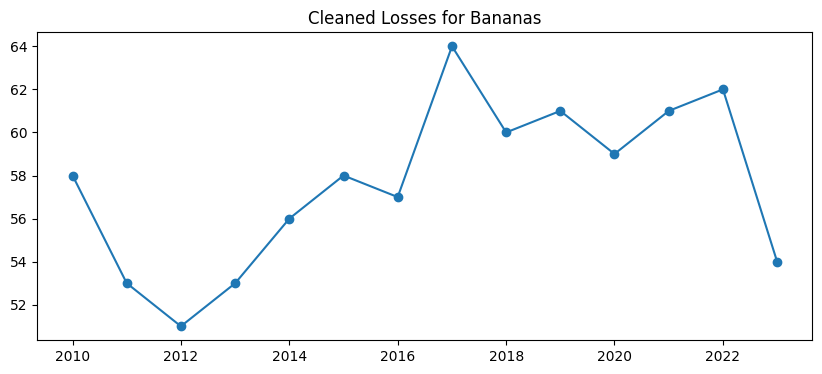

In [ ]:
# Step 3: Linear interpolation
item_df['Losses'] = item_df['Losses'].interpolate(method='linear').fillna(0)

plt.figure(figsize=(10, 4))
plt.plot(item_df.index, item_df['Losses'], marker='o')
plt.title(f"Cleaned Losses for {item}")
plt.show()

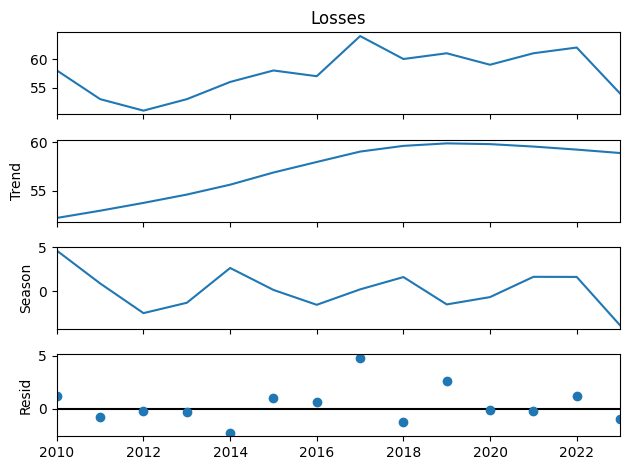

In [ ]:
# Step 4: Perform STL Decomposition
p = period_map.get(item, 4)
res = STL(item_df['Losses'], period=p, robust=True).fit()

# Assign raw components to the dataframe
item_df['Trend_Raw'] = res.trend
item_df['Seasonal_Raw'] = res.seasonal
item_df['Resid_Raw'] = res.resid

# Result Visualization
res.plot()
plt.show()

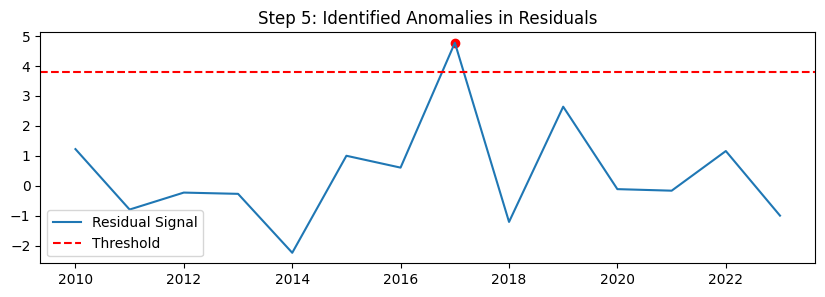

In [ ]:
# Step 5: Detect Outliers using IQR on Residuals
resid = item_df['Resid_Raw']
q1, q3 = resid.quantile(0.25), resid.quantile(0.75)
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Flag anomalies (1 = Outlier, 0 = Normal)
item_df['Is_Outlier'] = ((resid < lower_bound) | (resid > upper_bound)).astype(int)

# Result Visualization
plt.figure(figsize=(10, 3))
plt.plot(item_df.index, resid, label='Residual Signal')
plt.axhline(upper_bound, color='red', linestyle='--', label='Threshold')
plt.scatter(item_df[item_df['Is_Outlier']==1].index, item_df[item_df['Is_Outlier']==1]['Resid_Raw'], color='red')
plt.title("Step 5: Identified Anomalies in Residuals")
plt.legend()
plt.show()

In [ ]:
# Step 6: Augmented Dickey-Fuller Test
resid_p = adfuller(item_df['Resid_Raw'])[1]
print(f"Residual P-Value: {resid_p:.4f}")

# Stationarity Fix
if resid_p > 0.05:
    resid_processed = item_df['Resid_Raw'].diff().fillna(0)
    print("Action: Differencing applied to stabilize residuals.")
else:
    resid_processed = item_df['Resid_Raw']
    print("Action: Residuals are already stationary.")

Residual P-Value: 0.1332
Action: Differencing applied to stabilize residuals.


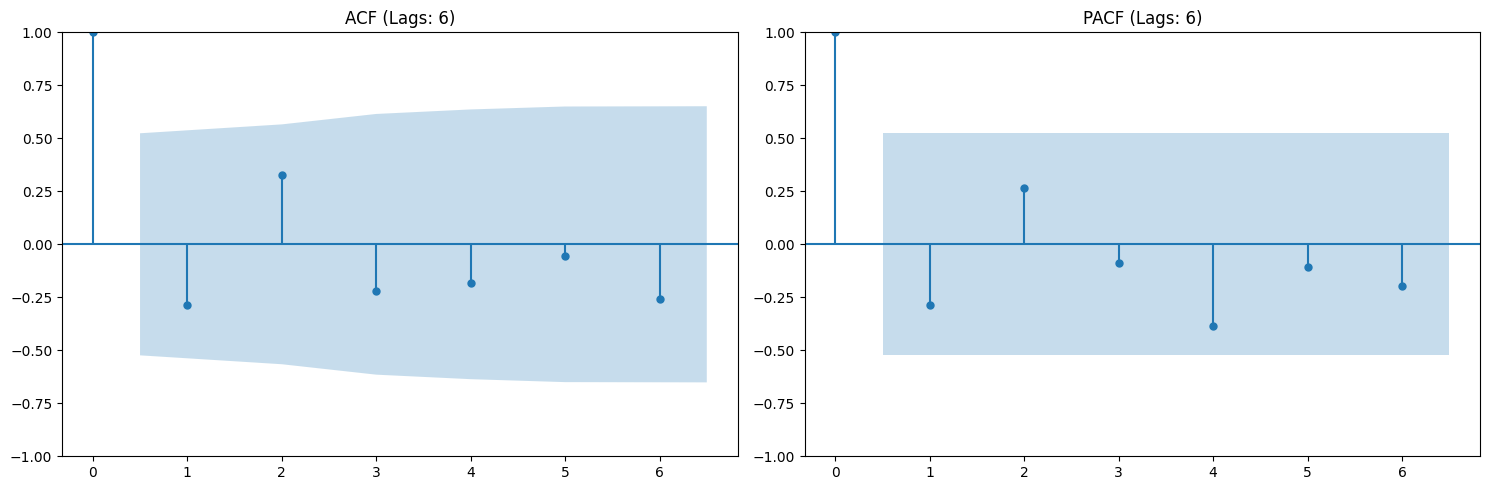

Analysis completed using 6 lags based on a sample size of 14.


In [ ]:
# Step 7: ACF and PACF

# Use the stationary residuals from a sample item (e.g., Bananas)
sample_resid = item_df['Resid_Raw']

# Determine the safe number of lags (50% of sample size - 1)
n_observations = len(sample_resid.dropna())
max_safe_lags = (n_observations // 2) - 1
requested_lags = min(10, max_safe_lags)

if requested_lags < 1:
    print("Insufficient data to perform ACF/PACF analysis for this item.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # ACF: Identifies seasonality and general memory
    plot_acf(sample_resid.dropna(), ax=ax1, lags=requested_lags)
    ax1.set_title(f'ACF (Lags: {requested_lags})')

    # PACF: Best for determining optimal input sequence length (Lookback window)
    plot_pacf(sample_resid.dropna(), ax=ax2, lags=requested_lags, method='ywm')
    ax2.set_title(f'PACF (Lags: {requested_lags})')

    plt.tight_layout()
    plt.show()

print(f"Analysis completed using {requested_lags} lags based on a sample size of {n_observations}.")

In [ ]:
# Step 8: Min-Max Normalization
scaler = StandardScaler()
scaled_features = scaler.fit_transform(np.column_stack([
    item_df['Trend_Raw'],
    item_df['Seasonal_Raw'],
    resid_processed
]))

item_df['Trend_Scaled'] = scaled_features[:, 0]
item_df['Seasonal_Scaled'] = scaled_features[:, 1]
item_df['Resid_Scaled'] = scaled_features[:, 2]

print("Preprocessing Complete. Rows of features:")
print(item_df[['Trend_Scaled', 'Seasonal_Scaled', 'Resid_Scaled']])

Preprocessing Complete. Rows of features:
            Trend_Scaled  Seasonal_Scaled  Resid_Scaled
Year                                                   
2010-01-01     -1.843773         2.078927      0.059222
2011-01-01     -1.565712         0.344243     -0.694034
2012-01-01     -1.266172        -1.224718      0.270536
2013-01-01     -0.945288        -0.675020      0.043519
2014-01-01     -0.565636         1.163770     -0.675160
2015-01-01     -0.098476         0.002220      1.268135
2016-01-01      0.306482        -0.784742     -0.088562
2017-01-01      0.706204         0.032435      1.615044
2018-01-01      0.925472         0.682895     -2.173184
2019-01-01      1.021637        -0.764040      1.495180
2020-01-01      0.992764        -0.376569     -0.968210
2021-01-01      0.898863         0.695765      0.039966
2022-01-01      0.782215         0.690352      0.553264
2023-01-01      0.651424        -1.865518     -0.745715


In [ ]:
processed_data_list = []
summary_results = []

for item in df_original['Item'].unique():
    # 1. Setup
    item_df = df_original[df_original['Item'] == item].copy()
    item_df['Year'] = pd.to_datetime(item_df['Year'].astype(str), format='%Y')
    item_df = item_df.sort_values('Year').set_index('Year').asfreq('YS')

    # 2. Cleaning & Interpolation
    if len(item_df.dropna(subset=['Losses'])) < 10 or item_df['Losses'].nunique() <= 1:
        continue
    item_df['Losses'] = item_df['Losses'].interpolate(method='linear').fillna(0)

    try:
        # 3. STL Decomposition
        p = period_map.get(item, 4)
        res = STL(item_df['Losses'], period=p, robust=True).fit()

        # 4. Outlier Detection (IQR Method)
        resid = res.resid
        q1, q3 = resid.quantile(0.25), resid.quantile(0.75)
        iqr = q3 - q1
        lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        # ADDED: Flagging outliers for the Attention layer
        item_df['Is_Outlier'] = ((resid < lb) | (resid > ub)).astype(int)

        # 5. Stationarity Check (ADF)
        raw_p = adfuller(item_df['Losses'])[1]
        resid_p = adfuller(resid)[1]

        # 6. Stationarity Fix (Differencing)
        resid_feat = resid.diff().fillna(0) if resid_p > 0.05 else resid

        # 7. Scaling (Min-Max)
        scaler = StandardScaler()
        scaled_feats = scaler.fit_transform(np.column_stack([res.trend, res.seasonal, resid_feat]))

        # 8. Assign Features
        item_df['Trend_Scaled'] = scaled_feats[:, 0]
        item_df['Seasonal_Scaled'] = scaled_feats[:, 1]
        item_df['Resid_Scaled'] = scaled_feats[:, 2]
        item_df['Item_Name'] = item

        processed_data_list.append(item_df.reset_index())
        summary_results.append({
            'Item': item, 'Period': p,
            'Outliers_Found': item_df['Is_Outlier'].sum(),
            'Resid_Stationary': "Yes" if resid_p < 0.05 else "No"
        })
    except Exception as e:
        print(f"Error on {item}: {e}")
        continue

# 9. Save final dataset
final_df = pd.concat(processed_data_list)
final_df.to_csv('final_processed_food_loss.csv', index=False)

# 10. Display summary for your report
summary_df = pd.DataFrame(summary_results)
print("\n--- Final Preprocessing Summary ---")
print(summary_df.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2



--- Final Preprocessing Summary ---
                    Item  Period  Outliers_Found Resid_Stationary
0                Bananas       4               1               No
1   Cassava and products       4               2               No
2          Citrus, Other       4               2               No
3  Coconuts - Incl Copra       3               2              Yes
4    Coffee and products       3               0              Yes


In [ ]:
df_final = pd.read_csv('final_processed_food_loss.csv')

print("DataFrame loaded successfully. Displaying the first 5 rows:")
display(df_final.head())

DataFrame loaded successfully. Displaying the first 5 rows:


,Year,Item,Domestic_Supply,Export,Feed,Import,Losses,Other uses (non-food),Processing,Production,...,IDR (%),Population,Domestic_Availability,PerCapita_Availability,PerCapita_Availability_kg,Is_Outlier,Trend_Scaled,Seasonal_Scaled,Resid_Scaled,Item_Name
0,2010-01-01,Bananas,313.0,21.0,0.0,2.0,58.0,0.0,0.0,333.0,...,0.636943,28655.78,314.0,0.010958,10.96,0,-1.843773,2.078927,0.059222,Bananas
1,2011-01-01,Bananas,286.0,23.0,0.0,2.0,53.0,0.0,0.0,306.0,...,0.701754,29162.04,285.0,0.009773,9.77,0,-1.565712,0.344243,-0.694034,Bananas
2,2012-01-01,Bananas,279.0,18.0,0.0,8.0,51.0,0.0,0.0,289.0,...,2.867384,29662.83,279.0,0.009406,9.41,0,-1.266172,-1.224718,0.270536,Bananas
3,2013-01-01,Bananas,286.0,19.0,0.0,16.0,53.0,0.0,0.0,289.0,...,5.594406,30174.26,286.0,0.009478,9.48,0,-0.945288,-0.675020,0.043519,Bananas
4,2014-01-01,Bananas,304.0,21.0,0.0,21.0,56.0,0.0,0.0,303.0,...,6.930693,30696.14,303.0,0.009871,9.87,0,-0.565636,1.163770,-0.675160,Bananas


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       378 non-null    object 
 1   Item                       378 non-null    object 
 2   Domestic_Supply            378 non-null    float64
 3   Export                     378 non-null    float64
 4   Feed                       378 non-null    float64
 5   Import                     378 non-null    float64
 6   Losses                     378 non-null    float64
 7   Other uses (non-food)      378 non-null    float64
 8   Processing                 378 non-null    float64
 9   Production                 378 non-null    float64
 10  Residuals                  378 non-null    float64
 11  Seed                       378 non-null    float64
 12  Stock_Variation            378 non-null    float64
 13  SSR (%)                    373 non-null    float64

In [ ]:
# Double check on items
unique_items_list = df_final['Item'].unique()
print(f"Total unique items: {len(unique_items_list)}")

for item in unique_items_list:
    print(item)

Total unique items: 27
=== FBS Items (Total: 31 ) ===
Bananas
Cassava and products
Citrus, Other
Coconuts - Incl Copra
Coffee and products
Eggs
Fats, Animals, Raw
Fruits, other
Grapefruit and products
Lemons, Limes and products
Maize and products
Milk - Excluding Butter
Nuts and products
Offals, Edible
Oilcrops, Other
Oranges, Mandarines
Palm Oil
Palm kernels
Palmkernel Oil
Pepper
Pineapples and products
Rape and Mustardseed
Rice and products
Roots, Other
Spices, Other
Sugar cane
Sweet potatoes
Tea (including mate)
Tomatoes and products
Vegetables, other
Yams


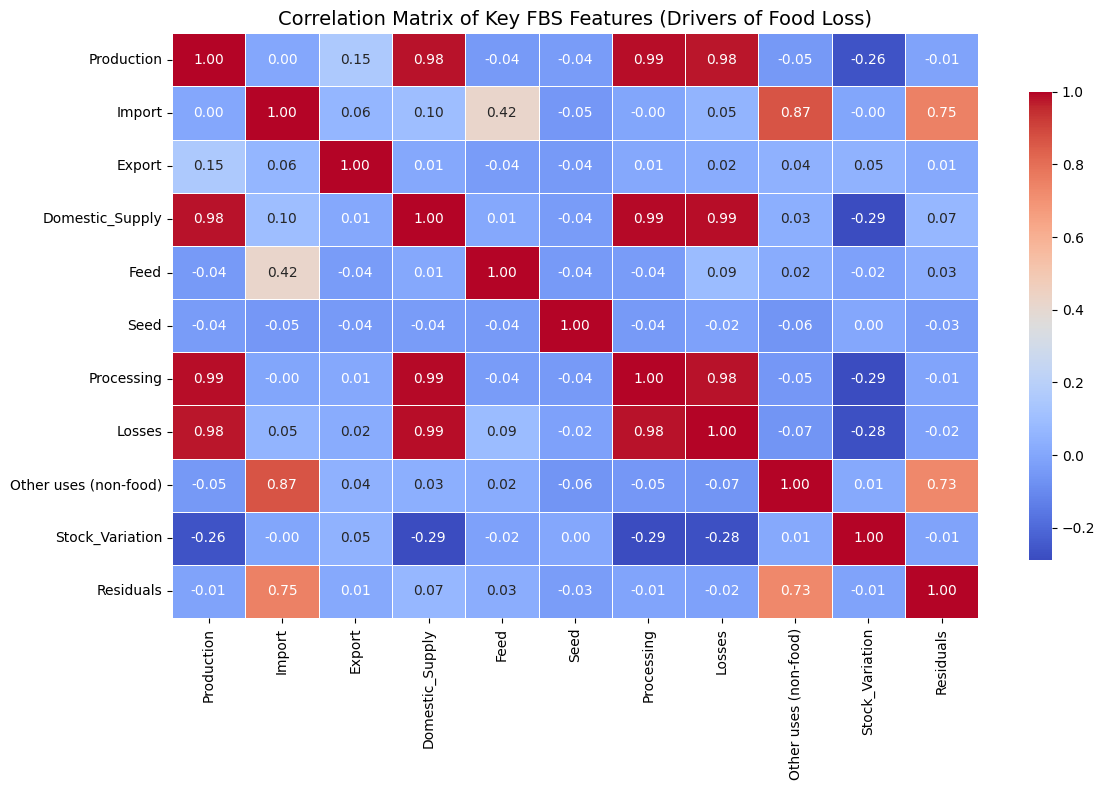

In [ ]:
cols_of_interest = [
    "Production", "Import", "Export", "Domestic_Supply", "Feed",
    "Seed", "Processing", "Losses", "Other uses (non-food)",
    "Stock_Variation", "Residuals"
]

# Compute and Plot Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_original[cols_of_interest].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Key FBS Features (Drivers of Food Loss)", fontsize=14)
plt.tight_layout()
plt.show()